Part 1:

Use the cifar10 dataset included with keras and construct a CNN to predict the image labels.\
Don't forget to visualize some images to understand the data.\
Train the network and visualize accuracy over epochs and check the output with outputing some predictions for visual comparison.


In [1]:
import keras

# load the cifar10 dataset from keras
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [ ]:
# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

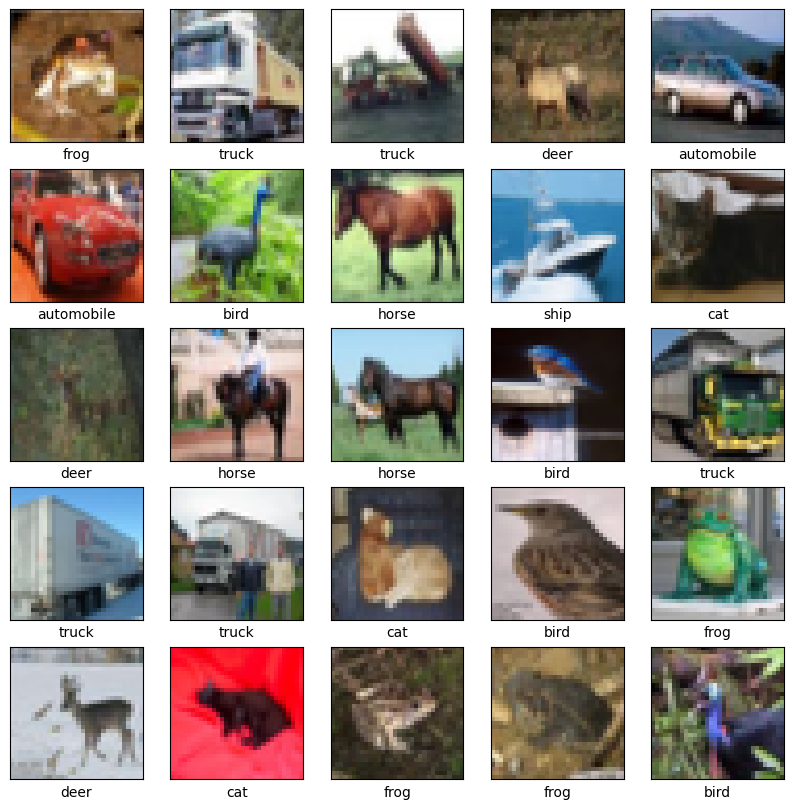

In [ ]:
# visualize some of the data
import matplotlib.pyplot as plt
import numpy as np

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

In [ ]:
# construct a CNN to predict the image labels
from keras import datasets, layers, models

model = models.Sequential()

# added the convolutional layers
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# flatten
model.add(layers.Flatten())

# fully connected layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))


In [ ]:
# display the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])


In [ ]:
# train the model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.3460 - loss: 1.7677 - val_accuracy: 0.5448 - val_loss: 1.2546
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5847 - loss: 1.1784 - val_accuracy: 0.6036 - val_loss: 1.1234
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6478 - loss: 0.9959 - val_accuracy: 0.6726 - val_loss: 0.9416
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6807 - loss: 0.9080 - val_accuracy: 0.6760 - val_loss: 0.9447
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7116 - loss: 0.8290 - val_accuracy: 0.6820 - val_loss: 0.9261
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7344 - loss: 0.7552 - val_accuracy: 0.7006 - val_loss: 0.8777
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7514 - loss: 0.7098 - val_accuracy: 0.6994 - val_loss: 0.9013
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7705 - loss: 0.6589 -

313/313 - 1s - 2ms/step - accuracy: 0.7070 - loss: 0.8821


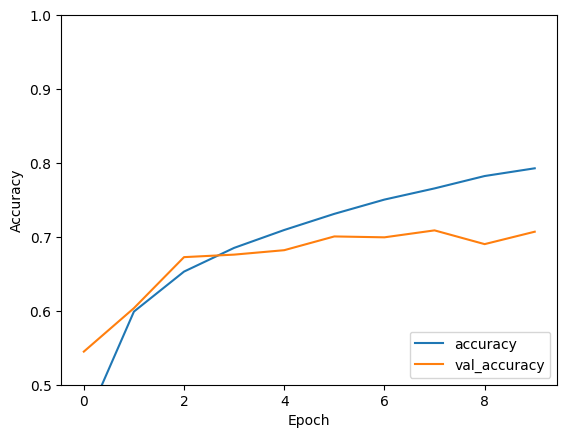

In [ ]:
# evaluate the model's accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


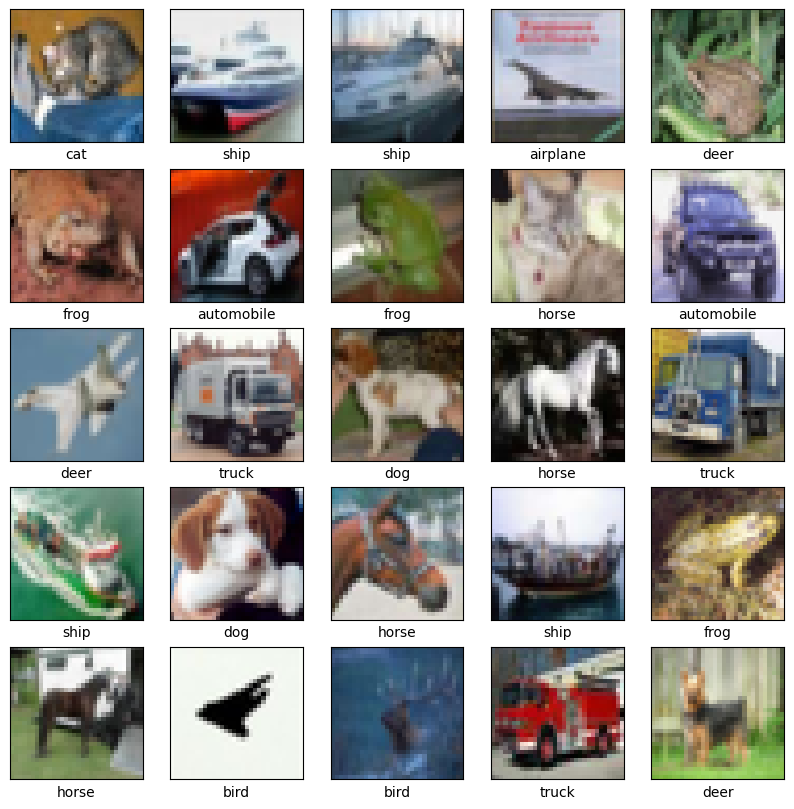

In [ ]:
# visualize predictions
predictions = model.predict(x_test)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names[np.argmax(predictions[i, :])])
plt.show()

Part 2:

Use the cifar100 dataset included with keras and repeat the experiment in Part 2.

In [ ]:
# load the cifar100 dataset from keras
(x_train100, y_train100), (x_test100, y_test100) = keras.datasets.cifar100.load_data(label_mode='fine')
assert x_train100.shape == (50000, 32, 32, 3)
assert x_test100.shape == (10000, 32, 32, 3)
assert y_train100.shape == (50000, 1)
assert y_test100.shape == (10000, 1)

In [ ]:
# Normalize pixel values to be between 0 and 1
x_train100, x_test100 = x_train100 / 255.0, x_test100 / 255.0

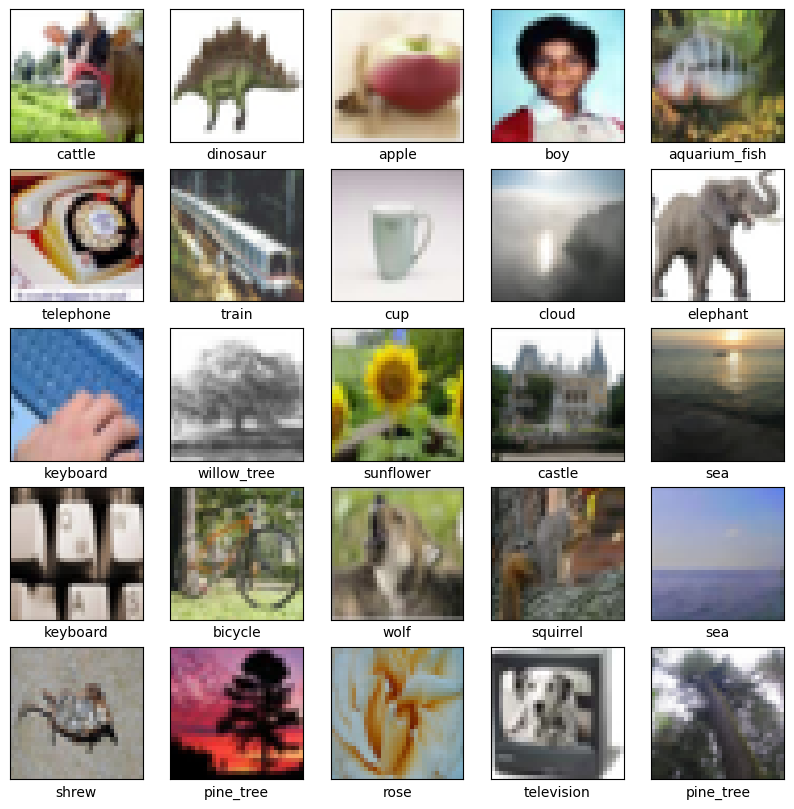

In [ ]:
# visualize some of the data
class_names100 = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train100[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names100[y_train100[i][0]])
plt.show()

In [ ]:
# construct a CNN to predict the image labels
model100 = models.Sequential()

# added the convolutional layers
model100.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model100.add(layers.MaxPooling2D((2, 2)))
model100.add(layers.Conv2D(64, (3, 3), activation='relu'))
model100.add(layers.MaxPooling2D((2, 2)))
model100.add(layers.Conv2D(64, (3, 3), activation='relu'))

# flatten
model100.add(layers.Flatten())

# fully connected layers
model100.add(layers.Dense(1024, activation='relu'))
model100.add(layers.Dense(512, activation='relu'))
model100.add(layers.Dense(256, activation='relu'))
model100.add(layers.Dense(100))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# display the model
model100.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 738,148 (2.82 MB)

 Trainable params: 738,148 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model100.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [ ]:
# train the model
history100 = model100.fit(x_train100, y_train100, epochs=10, validation_data=(x_test100, y_test100))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.0540 - loss: 4.1990 - val_accuracy: 0.1767 - val_loss: 3.4126
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2023 - loss: 3.2550 - val_accuracy: 0.2531 - val_loss: 3.0461
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2787 - loss: 2.8775 - val_accuracy: 0.2956 - val_loss: 2.8697
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3337 - loss: 2.6051 - val_accuracy: 0.3141 - val_loss: 2.7475
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3768 - loss: 2.3952 - val_accuracy: 0.3301 - val_loss: 2.6639
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4155 - loss: 2.2062 - val_accuracy: 0.3343 - val_loss: 2.6869
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4575 - loss: 2.0192 - val_accuracy: 0.3485 - val_loss: 2.6493
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4916 - loss: 1.8517

313/313 - 1s - 2ms/step - accuracy: 0.3440 - loss: 2.9293


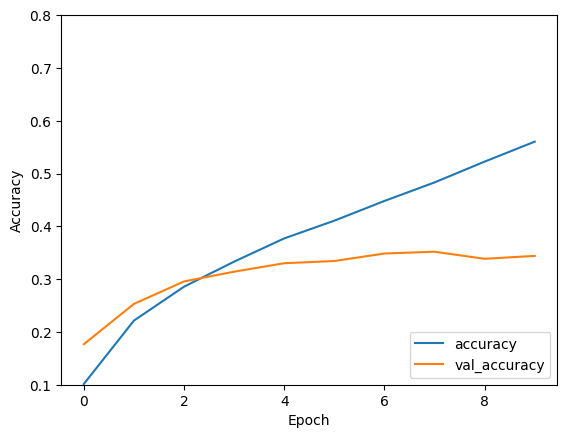

In [ ]:
# evaluate the model's accuracy
plt.plot(history100.history['accuracy'], label='accuracy')
plt.plot(history100.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.1, 0.8])
plt.legend(loc='lower right')

test_loss100, test_acc100 = model100.evaluate(x_test100,  y_test100, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


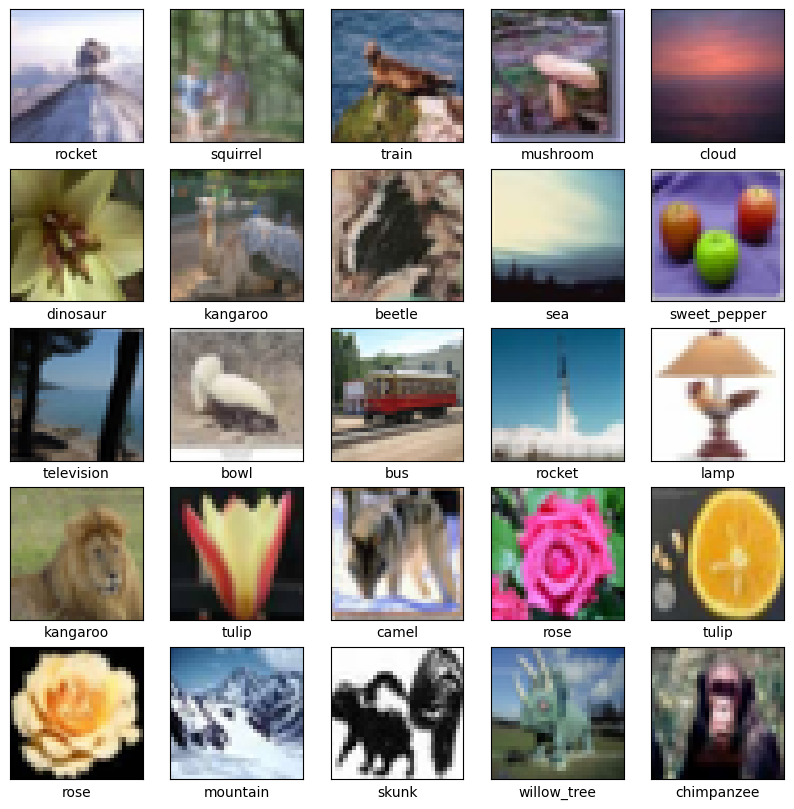

In [ ]:
# visualize predictions
predictions100 = model100.predict(x_test100)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test100[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names100[np.argmax(predictions100[i, :])])
plt.show()

Part3:

Use the Animal10 dataset in moodle to repeat the experiment. See also the Kaggle
page.\
a)

Download images to your computer and load the data organized as training and
testing data (use 20% for testing).\
Explore and visualize some of the data to gain a better understanding of the problem.\
You can use tensorflow's image_dataset_from_directory function and other standard functions to scale the dataset to the same input sizes, etc...\
b)

Explore the dataset.\
Visualize some images, check image sizes, number of images in each folder.\
c)

Perform operations to achieve a balanced dataset (use undersampling or data
augmentation).\
d)

Construct a Convolutional Neural Network to predict the correct label, and train it.\
Tune the structure and hyperparameters for best accuracy.\
Visualize accuracy over the training epochs.

In [3]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# unzip the dataset into a working directory
!unzip /content/drive/MyDrive/Animals10.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: /content/raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: /content/raw-img/ragno/OIP-MgrKq05YHGXsgj1AmYIyJQHaE8.jpeg  
  inflating: /content/raw-img/ragno/OIP-MhRGx7d8nbnHBuqrsO00E

In [24]:
import os
import random

data_dir = "/content/raw-img"

# Get class folders
class_names = sorted(os.listdir(data_dir))
class_paths = [os.path.join(data_dir, c) for c in class_names]

In [25]:
# Count images per class
class_image_counts = {}
for class_name in class_names:
    class_folder = os.path.join(data_dir, class_name)
    images = os.listdir(class_folder)
    class_image_counts[class_name] = len(images)

In [26]:
# Find smallest class size
min_class_size = min(class_image_counts.values())
print("Smallest class size:", min_class_size)

Smallest class size: 1446


In [27]:
# Remove extra images from larger classes
for class_name in class_names:
    class_folder = os.path.join(data_dir, class_name)
    images = os.listdir(class_folder)

    if len(images) > min_class_size:
        images_to_remove = random.sample(
            images,
            len(images) - min_class_size
        )

        for img in images_to_remove:
            os.remove(os.path.join(class_folder, img))

print("All classes are now balanced.")

All classes are now balanced.


In [28]:
import keras
img_height = 128
img_width = 128
batch_size = 32

# build training data
(animals10_train, animals10_test) = keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="both",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 14460 files belonging to 10 classes.
Using 11568 files for training.
Using 2892 files for validation.


In [33]:
from keras import applications

# import pre-trained weights
base_model = applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [34]:
base_model.trainable = False

In [39]:
from keras import datasets, layers, models

# construct a CNN to predict the image labels
modelA = models.Sequential()
modelA.add(layers.Rescaling(1./255, input_shape=(128, 128, 3)))
modelA.add(layers.RandomFlip("horizontal_and_vertical"))
modelA.add(layers.RandomRotation(0.2))

# added the convolutional layers
modelA.add(base_model)
# modelA.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
# modelA.add(layers.MaxPooling2D((2, 2)))
# modelA.add(layers.Conv2D(64, (3, 3), activation='relu'))
# modelA.add(layers.MaxPooling2D((2, 2)))
# modelA.add(layers.Conv2D(64, (3, 3), activation='relu'))

# flatten
modelA.add(layers.Flatten())

# fully connected layers
modelA.add(layers.Dense(64, activation='relu'))
modelA.add(layers.Dense(32, activation='relu'))
modelA.add(layers.Dense(10))

In [40]:
import keras

# compile the model
modelA.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])


In [41]:
# display the model
modelA.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,450 (58.14 MB)

 Trainable params: 526,762 (2.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [42]:
# train the model
historyA = modelA.fit(animals10_train, epochs=10, validation_data=animals10_test)

Epoch 1/10
 25/362 ━━━━━━━━━━━━━━━━━━━━ 32:03 6s/step - accuracy: 0.1251 - loss: 2.3343

KeyboardInterrupt: 

In [ ]:
# evaluate the model's accuracy
plt.plot(historyA.history['accuracy'], label='accuracy')
plt.plot(historyA.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.1, 0.8])
plt.legend(loc='lower right')

#test_lossA, test_accA = model100.evaluate(x_test100,  y_test100, verbose=2)

In [ ]:
# import numpy as np

# # build precise training and validation sets
# x_train = []
# y_train = []
# for x, y in animals10_train:
#   x_train.append(x)
#   y_train.append(y)

# x_test = []
# y_test = []
# for x, y in animals10_test:
#   x_test.append(x)
#   y_test.append(y)

# assert x_train.shape == (20944, 222, 222, 3)
# assert y_train.shape == (20944,)
# assert x_test.shape == (5235, 222, 222, 3)
# assert y_test.shape == (5235,)